<a href="https://colab.research.google.com/github/mohammadNaelIsmail/transfer-learning-flowers/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow_datasets as tfds

print(tfds.__version__)

4.9.9


In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds

IMG_SIZE = 224
BATCH_SIZE = 16

(ds_train, ds_val, ds_test), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val   = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [15]:
import tensorflow as tf

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=3,
    callbacks=[early_stop]
)

Epoch 1/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 601s 4s/step - accuracy: 0.8365 - loss: 0.4810 - val_accuracy: 0.9093 - val_loss: 0.2768
Epoch 2/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 588s 4s/step - accuracy: 0.9350 - loss: 0.1852 - val_accuracy: 0.9111 - val_loss: 0.2759
Epoch 3/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 587s 4s/step - accuracy: 0.9568 - loss: 0.1146 - val_accuracy: 0.8966 - val_loss: 0.2682


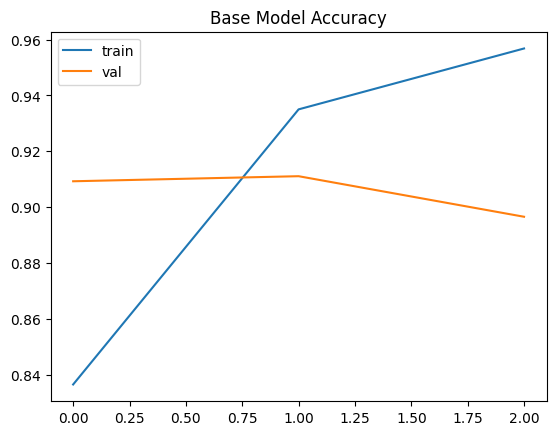

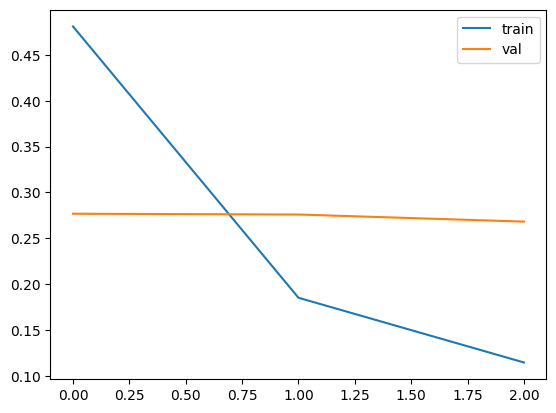

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Base Model Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(ds_test)
print("Test Accuracy:", test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.9055 - loss: 0.2989
Test Accuracy: 0.9054545164108276


In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history_ft = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=3,
    callbacks=[early_stop]
)

Epoch 1/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 831s 5s/step - accuracy: 0.9420 - loss: 0.1875 - val_accuracy: 0.9147 - val_loss: 0.2265
Epoch 2/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 767s 5s/step - accuracy: 0.9805 - loss: 0.0875 - val_accuracy: 0.9274 - val_loss: 0.2150
Epoch 3/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 762s 5s/step - accuracy: 0.9914 - loss: 0.0545 - val_accuracy: 0.9310 - val_loss: 0.2050


In [24]:
history_ft2 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=3,
    callbacks=[early_stop]
)

Epoch 1/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 768s 5s/step - accuracy: 0.9949 - loss: 0.0372 - val_accuracy: 0.9310 - val_loss: 0.2062
Epoch 2/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 844s 5s/step - accuracy: 0.9977 - loss: 0.0238 - val_accuracy: 0.9347 - val_loss: 0.2015
Epoch 3/3
161/161 ━━━━━━━━━━━━━━━━━━━━ 811s 5s/step - accuracy: 0.9992 - loss: 0.0202 - val_accuracy: 0.9365 - val_loss: 0.1984


In [25]:
import time

batch = next(iter(ds_test.take(1)))[0]

start = time.time()
pred = model.predict(batch)
end = time.time()

print("Inference time:", end - start)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Inference time: 8.871041536331177
